In [16]:
import catboost


ModuleNotFoundError: No module named 'ensemble_learning.ensembles'

In [ ]:
catboost.__version__

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
)
from catboost import CatBoostRegressor, Pool

### Dataset Insurance prediction


In [ ]:
insurance_data = pd.read_csv("../datasets/insurance.csv")

In [ ]:
insurance_data.info()

In [ ]:
insurance_data.head()

In [ ]:
X = insurance_data.drop("charges", axis=1)
y = insurance_data["charges"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

In [44]:
categorical_features = insurance_data.select_dtypes(exclude=np.number).columns.tolist()
print(categorical_features)
insurance_data[categorical_features] = insurance_data[categorical_features].astype("str").fillna('nan')

['sex', 'smoker', 'region']


In [19]:
X = insurance_data.drop("charges", axis=1)
y = insurance_data["charges"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((1070, 6), (268, 6))

In [20]:
train_pool = Pool(X_train, y_train, cat_features=categorical_features)
test_pool = Pool(X_test, y_test, cat_features=categorical_features)

In [21]:
model = CatBoostRegressor(
    iterations=200,
    learning_rate=0.1, # szybkość uczenia
    depth=6,
    loss_function="RMSE",
    verbose=20,
)

model.fit(train_pool)

0:	learn: 11131.4972651	total: 51.7ms	remaining: 10.3s
20:	learn: 4865.9620877	total: 101ms	remaining: 862ms
40:	learn: 4390.8127179	total: 154ms	remaining: 597ms
60:	learn: 4289.8396830	total: 185ms	remaining: 423ms
80:	learn: 4217.5644725	total: 235ms	remaining: 345ms
100:	learn: 4151.2047582	total: 298ms	remaining: 292ms
120:	learn: 4037.5768034	total: 359ms	remaining: 234ms
140:	learn: 3945.2295008	total: 387ms	remaining: 162ms
160:	learn: 3892.8692667	total: 426ms	remaining: 103ms
180:	learn: 3828.8975749	total: 463ms	remaining: 48.6ms
199:	learn: 3760.1923162	total: 498ms	remaining: 0us


CatBoostRegressor(depth=6, iterations=200, learning_rate=0.1, loss_function='RMSE', verbose=20)

In [52]:
def compute_metrics(model):
    y_pred = model.predict(test_pool)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"MAE: {mae}")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"R2 Score: {r2}")

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(y_test, y_pred, alpha=0.5)
    # ax.add_line()

    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
    ax.set_title("Predicted vs Actual Price")
    ax.grid(alpha=0.3)

    fig.tight_layout()
    plt.show()

MAE: 2294.6629317190527
MSE: 18723284.472430564
RMSE: 4327.041075888992
R2 Score: 0.879398148425949


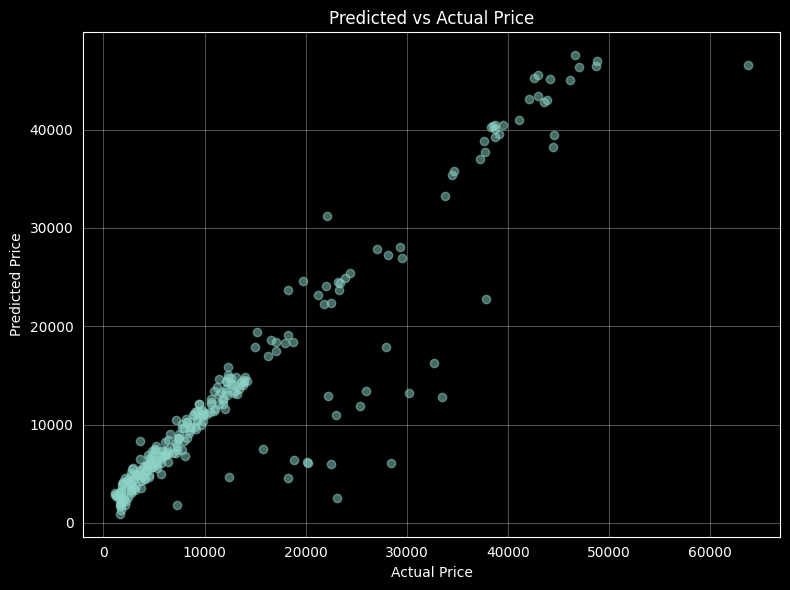

In [53]:
compute_metrics(model)

In [47]:
X_train_es, X_val, y_train_es, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

X_train_es.shape, X_val.shape

train_pool = Pool(X_train_es, y_train_es, cat_features=categorical_features)

val_pool = Pool(X_val, y_val, cat_features=categorical_features)

test_pool = Pool(X_test, y_test, cat_features=categorical_features)

In [49]:
%%timeit
model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05, # szybkość uczenia
    depth=6,
    loss_function="RMSE",
    subsample=0.8,
    bootstrap_type="Bernoulli",
    od_type="Iter",
    od_wait=40,
    verbose=50,
)

model.fit(train_pool)

0:	learn: 11414.0354093	total: 7.62ms	remaining: 2.28s
50:	learn: 4539.6453047	total: 106ms	remaining: 520ms
100:	learn: 4124.1624433	total: 175ms	remaining: 346ms
150:	learn: 3910.8618897	total: 291ms	remaining: 287ms
200:	learn: 3701.4818351	total: 399ms	remaining: 197ms
250:	learn: 3529.4797601	total: 515ms	remaining: 101ms
299:	learn: 3379.4050142	total: 640ms	remaining: 0us
0:	learn: 11414.0354093	total: 3.38ms	remaining: 1.01s
50:	learn: 4539.6453047	total: 83.8ms	remaining: 409ms
100:	learn: 4124.1624433	total: 150ms	remaining: 296ms
150:	learn: 3910.8618897	total: 229ms	remaining: 226ms
200:	learn: 3701.4818351	total: 326ms	remaining: 161ms
250:	learn: 3529.4797601	total: 415ms	remaining: 81ms
299:	learn: 3379.4050142	total: 514ms	remaining: 0us
0:	learn: 11414.0354093	total: 4.07ms	remaining: 1.22s
50:	learn: 4539.6453047	total: 73.7ms	remaining: 360ms
100:	learn: 4124.1624433	total: 132ms	remaining: 260ms
150:	learn: 3910.8618897	total: 197ms	remaining: 194ms
200:	learn: 3701

In [55]:
%lsmagic

Available line magics:
%alias  %alias_magic  %autoawait  %autocall  %automagic  %autosave  %bookmark  %cat  %cd  %clear  %code_wrap  %colors  %conda  %config  %connect_info  %cp  %debug  %dhist  %dirs  %doctest_mode  %ed  %edit  %env  %gui  %hist  %history  %killbgscripts  %ldir  %less  %lf  %lk  %ll  %load  %load_ext  %loadpy  %logoff  %logon  %logstart  %logstate  %logstop  %ls  %lsmagic  %lx  %macro  %magic  %mamba  %man  %matplotlib  %micromamba  %mkdir  %more  %mv  %notebook  %page  %pastebin  %pdb  %pdef  %pdoc  %pfile  %pinfo  %pinfo2  %pip  %popd  %pprint  %precision  %prun  %psearch  %psource  %pushd  %pwd  %pycat  %pylab  %qtconsole  %quickref  %recall  %rehashx  %reload_ext  %rep  %rerun  %reset  %reset_selective  %rm  %rmdir  %run  %save  %sc  %set_env  %store  %sx  %system  %tb  %time  %timeit  %unalias  %unload_ext  %uv  %who  %who_ls  %whos  %xdel  %xmode

Available cell magics:
%%!  %%HTML  %%SVG  %%bash  %%capture  %%code_wrap  %%debug  %%file  %%html  %%javascript  %%

MAE: 2294.6629317190527
MSE: 18723284.472430564
RMSE: 4327.041075888992
R2 Score: 0.879398148425949


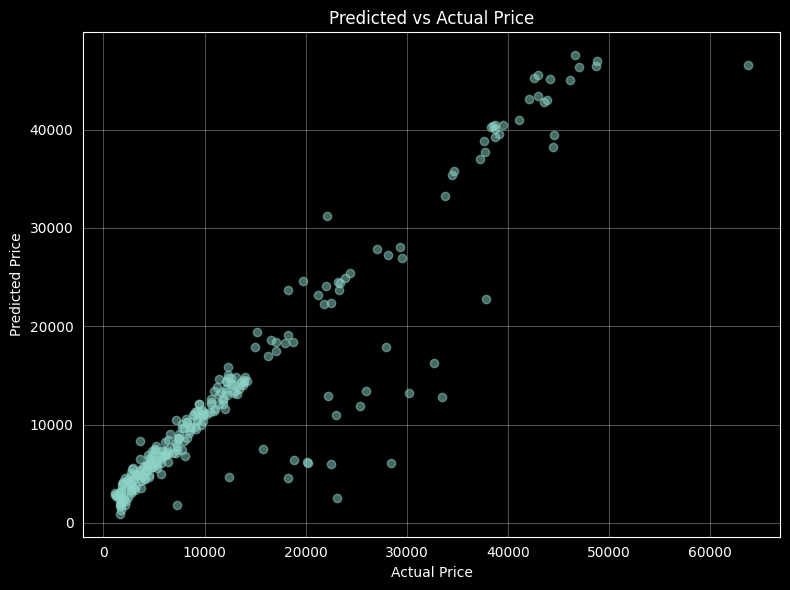

In [54]:
compute_metrics(model)

In [56]:
X.shape

(1338, 6)

    Feature  Importance
4    smoker   74.269323
2       bmi   14.080614
0       age    9.360705
3  children    1.299580
5    region    0.760590
1       sex    0.229188


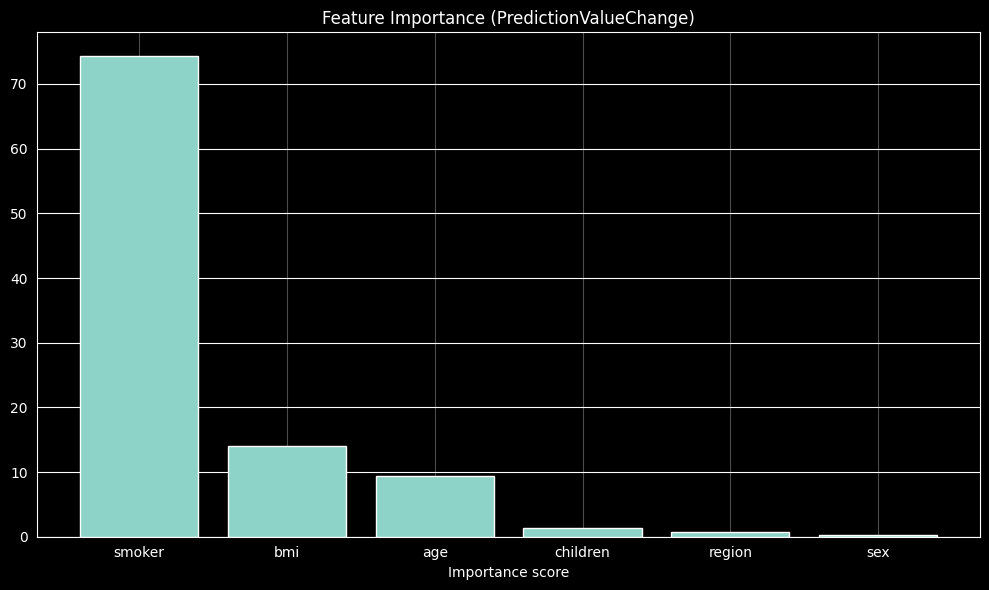

In [64]:
importance_pvc = model.get_feature_importance(train_pool, type="PredictionValuesChange")

feature_importance_df = (
    pd.DataFrame(
        {
            "Feature": X.columns,
            "Importance": importance_pvc
        }
    )
    .sort_values("Importance", ascending=False)
)


print(feature_importance_df)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

ax.set_title("Feature Importance (PredictionValueChange)")
ax.set_xlabel("Importance score")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.3)

fig.tight_layout()
plt.show()

# snapshot support

In [65]:
params = {
    'iterations': 5,
    'learning_rate': 0.5,
    'depth': 6,
    'loss_function': 'RMSE',
    'bootstrap_type': 'Bernoulli',
    'subsample': 0.8,
    'logging_level': 'Verbose'
}

In [66]:
model = CatBoostRegressor(**params).fit(train_pool, eval_set=val_pool, save_snapshot=True)

0:	learn: 7715.1550706	test: 8522.1324187	best: 8522.1324187 (0)	total: 2.47ms	remaining: 9.89ms
1:	learn: 5795.5383820	test: 6590.3182168	best: 6590.3182168 (1)	total: 7.07ms	remaining: 10.6ms
2:	learn: 5274.0651898	test: 6147.6864116	best: 6147.6864116 (2)	total: 8.56ms	remaining: 5.71ms
3:	learn: 4694.9351354	test: 5552.8755915	best: 5552.8755915 (3)	total: 9.79ms	remaining: 2.45ms
4:	learn: 4414.5201033	test: 5352.1075277	best: 5352.1075277 (4)	total: 11.1ms	remaining: 0us

bestTest = 5352.107528
bestIteration = 4



In [67]:
params.update({
    "iterations":20,
    "learning_rate":0.1,
})
model = CatBoostRegressor(**params).fit(train_pool, eval_set=val_pool, save_snapshot=True)

5:	learn: 4387.7281950	test: 5339.4474244	best: 5339.4474244 (5)	total: 12ms	remaining: 12.4ms
6:	learn: 4358.2241649	test: 5328.8149780	best: 5328.8149780 (6)	total: 13.8ms	remaining: 17.9ms
7:	learn: 4337.7950335	test: 5324.9906033	best: 5324.9906033 (7)	total: 15.1ms	remaining: 16ms
8:	learn: 4322.1225730	test: 5321.0197037	best: 5321.0197037 (8)	total: 16.6ms	remaining: 15.1ms
9:	learn: 4305.4357663	test: 5314.7263431	best: 5314.7263431 (9)	total: 18.2ms	remaining: 14.2ms
10:	learn: 4294.9486435	test: 5313.3350035	best: 5313.3350035 (10)	total: 18.9ms	remaining: 11.6ms
11:	learn: 4288.2110789	test: 5312.2211950	best: 5312.2211950 (11)	total: 19.7ms	remaining: 9.8ms
12:	learn: 4270.6525807	test: 5314.0036122	best: 5312.2211950 (11)	total: 23.6ms	remaining: 10.9ms
13:	learn: 4267.7077572	test: 5311.1395102	best: 5311.1395102 (13)	total: 24.5ms	remaining: 8.92ms
14:	learn: 4262.0381057	test: 5308.6292023	best: 5308.6292023 (14)	total: 25ms	remaining: 6.94ms
15:	learn: 4247.8153682	tes